# Model Evaluation: Base vs Fine-tuned

This notebook evaluates **Qwen2.5-1.5B-Instruct** before and after fine-tuning on the comment intent benchmark.

Run this on RunPod before triggering training to get base model scores, then again after training to compare.

**Required files:**
- `benchmark.csv` — columns: `comment`, `intent`
- adapter folder (for fine-tuned evaluation only)

## 0. Install dependencies

In [1]:
!pip install -q transformers peft accelerate bitsandbytes pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


## 1. Config — edit these paths

In [12]:
BASE_MODEL     = "Qwen/Qwen2.5-1.5B-Instruct"
ADAPTER_PATH   = "/workspace/comment-intent/v1/output/"  # path to your LoRA adapter
BENCHMARK_PATH = "benchmark.csv"                          # upload this to RunPod or set full path

VALID_LABELS = {"Complaint", "Question", "Suggestion", "Statement", "Praise"}

SYSTEM_PROMPT = (
    "You are a strict text classification system.\n"
    "Classify the comment into exactly one of these labels:\n"
    "Question, Complaint, Statement, Praise, Suggestion.\n"
    "Return ONLY valid JSON in this exact format:\n"
    '{\"predicted_intent\": \"<label>\"}\n'
    "Do not output anything else."
)

print("Config ready.")

Config ready.


## 2. Load benchmark

Benchmark loaded: 375 rows

intent
Question      217
Complaint      95
Statement      48
Praise         10
Suggestion      5


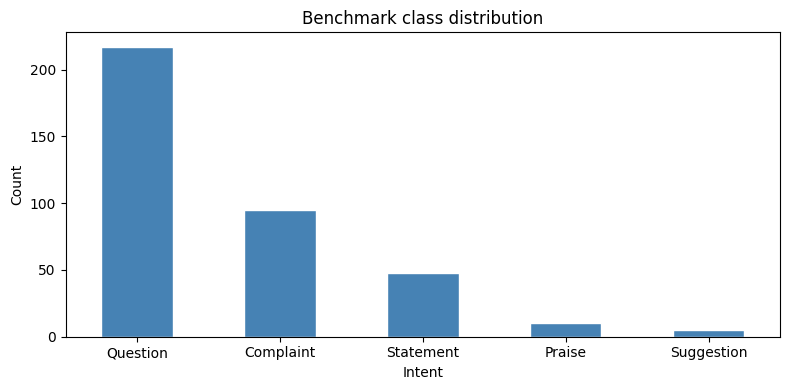

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(BENCHMARK_PATH)
df = df.dropna(subset=["comment", "intent"]).reset_index(drop=True)
df["intent"] = df["intent"].str.strip().str.capitalize()

print(f"Benchmark loaded: {len(df)} rows")
print()
print(df["intent"].value_counts().to_string())

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 4))
df["intent"].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Benchmark class distribution")
ax.set_xlabel("Intent")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Inference helper

In [4]:
import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline


def load_model(base_model: str, adapter_path: str = None):
    """Load base model or base + LoRA adapter."""
    label = "fine-tuned" if adapter_path else "base"
    print(f"Loading {label} model...")

    tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        base_model,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )

    if adapter_path:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, adapter_path)

    model.eval()

    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=32,
        do_sample=False,
    )
    print(f"{label.capitalize()} model ready.")
    return pipe


def predict(pipe, comment: str) -> str | None:
    tokenizer = pipe.tokenizer
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": f"Comment:\n{comment}"},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    output    = pipe(prompt)[0]["generated_text"]
    generated = output[len(prompt):].strip()

    try:
        start  = generated.find("{")
        end    = generated.rfind("}") + 1
        intent = json.loads(generated[start:end]).get("predicted_intent", "").strip().capitalize()
        return intent if intent in VALID_LABELS else None
    except Exception:
        return None


def run_evaluation(pipe, df: pd.DataFrame, label: str) -> dict:
    from sklearn.metrics import accuracy_score, classification_report, f1_score

    y_true, y_pred = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        pred = predict(pipe, str(row["comment"]))
        y_true.append(row["intent"])
        y_pred.append(pred)
        if (i + 1) % 25 == 0:
            print(f"  [{label}] {i + 1}/{len(df)}")

    failed = sum(1 for p in y_pred if p is None)
    pairs  = [(t, p) for t, p in zip(y_true, y_pred) if p is not None]
    yt     = [t for t, p in pairs]
    yp     = [p for t, p in pairs]

    return {
        "label":       label,
        "accuracy":    round(accuracy_score(yt, yp), 4),
        "f1_macro":    round(f1_score(yt, yp, average="macro",    zero_division=0), 4),
        "f1_weighted": round(f1_score(yt, yp, average="weighted", zero_division=0), 4),
        "total":       len(y_true),
        "failed":      failed,
        "report":      classification_report(yt, yp, zero_division=0),
        "y_true":      yt,
        "y_pred":      yp,
    }

print("Helpers ready.")

Helpers ready.


## 4. Evaluate base model (no fine-tuning)

In [5]:
base_pipe    = load_model(BASE_MODEL)
base_results = run_evaluation(base_pipe, df, label="base")

print(f"\n{'='*50}")
print(f"BASE MODEL RESULTS")
print(f"{'='*50}")
print(f"Accuracy     : {base_results['accuracy']}")
print(f"F1 Macro     : {base_results['f1_macro']}")
print(f"F1 Weighted  : {base_results['f1_weighted']}")
print(f"Failed preds : {base_results['failed']}/{base_results['total']}")
print(f"\nClassification Report:\n{base_results['report']}")

# Free GPU memory before loading fine-tuned model
del base_pipe
torch.cuda.empty_cache()

Loading base model...


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Base model ready.


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  [base] 25/375
  [base] 50/375
  [base] 75/375
  [base] 100/375
  [base] 125/375
  [base] 150/375
  [base] 175/375
  [base] 200/375
  [base] 225/375
  [base] 250/375
  [base] 275/375
  [base] 300/375
  [base] 325/375
  [base] 350/375
  [base] 375/375

BASE MODEL RESULTS
Accuracy     : 0.3547
F1 Macro     : 0.2483
F1 Weighted  : 0.3095
Failed preds : 0/375

Classification Report:
              precision    recall  f1-score   support

   Complaint       0.42      0.95      0.58        95
      Praise       0.50      0.20      0.29        10
    Question       1.00      0.13      0.24       217
   Statement       0.09      0.25      0.14        48
  Suggestion       0.00      0.00      0.00         5

    accuracy                           0.35       375
   macro avg       0.40      0.31      0.25       375
weighted avg       0.71      0.35      0.31       375



## 5. Evaluate fine-tuned model

In [13]:
ft_pipe    = load_model(BASE_MODEL, adapter_path=ADAPTER_PATH)
ft_results = run_evaluation(ft_pipe, df, label="fine-tuned")

print(f"\n{'='*50}")
print(f"FINE-TUNED MODEL RESULTS")
print(f"{'='*50}")
print(f"Accuracy     : {ft_results['accuracy']}")
print(f"F1 Macro     : {ft_results['f1_macro']}")
print(f"F1 Weighted  : {ft_results['f1_weighted']}")
print(f"Failed preds : {ft_results['failed']}/{ft_results['total']}")
print(f"\nClassification Report:\n{ft_results['report']}")

Loading fine-tuned model...


Device set to use cuda:0


Fine-tuned model ready.
  [fine-tuned] 25/375
  [fine-tuned] 50/375
  [fine-tuned] 75/375
  [fine-tuned] 100/375
  [fine-tuned] 125/375
  [fine-tuned] 150/375
  [fine-tuned] 175/375
  [fine-tuned] 200/375
  [fine-tuned] 225/375
  [fine-tuned] 250/375
  [fine-tuned] 275/375
  [fine-tuned] 300/375
  [fine-tuned] 325/375
  [fine-tuned] 350/375
  [fine-tuned] 375/375

FINE-TUNED MODEL RESULTS
Accuracy     : 0.7813
F1 Macro     : 0.5159
F1 Weighted  : 0.7901
Failed preds : 0/375

Classification Report:
              precision    recall  f1-score   support

   Complaint       0.71      0.89      0.79        95
      Praise       0.50      0.30      0.38        10
    Question       0.99      0.80      0.88       217
   Statement       0.44      0.67      0.53        48
  Suggestion       0.00      0.00      0.00         5

    accuracy                           0.78       375
   macro avg       0.53      0.53      0.52       375
weighted avg       0.82      0.78      0.79       375



## 6. Comparison

              Model  Accuracy  F1 Macro  F1 Weighted  Failed Preds
Base (no fine-tune)    0.3547    0.2483       0.3095             0
  Fine-tuned (LoRA)    0.7813    0.5159       0.7901             0


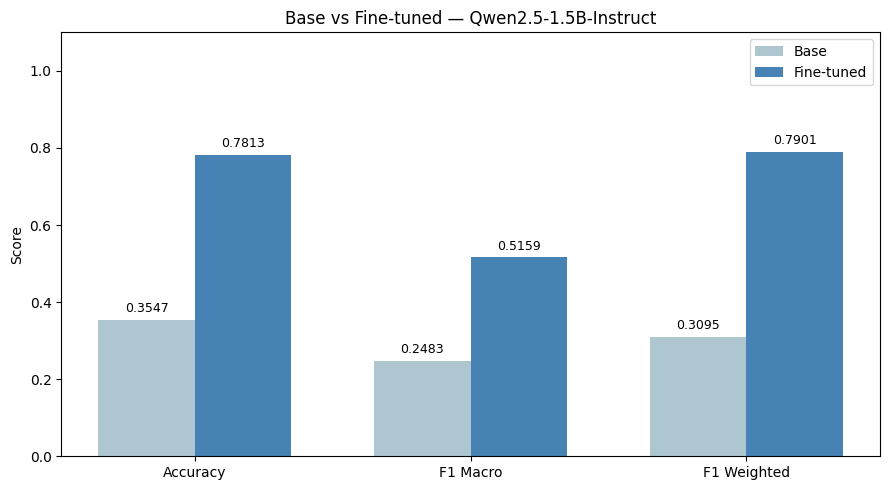

Chart saved to base_vs_finetuned.png


In [14]:
comparison = pd.DataFrame([
    {
        "Model":        "Base (no fine-tune)",
        "Accuracy":     base_results["accuracy"],
        "F1 Macro":     base_results["f1_macro"],
        "F1 Weighted":  base_results["f1_weighted"],
        "Failed Preds": base_results["failed"],
    },
    {
        "Model":        "Fine-tuned (LoRA)",
        "Accuracy":     ft_results["accuracy"],
        "F1 Macro":     ft_results["f1_macro"],
        "F1 Weighted":  ft_results["f1_weighted"],
        "Failed Preds": ft_results["failed"],
    },
])

print(comparison.to_string(index=False))

# Bar chart
metrics = ["Accuracy", "F1 Macro", "F1 Weighted"]
base_vals = [base_results["accuracy"], base_results["f1_macro"], base_results["f1_weighted"]]
ft_vals   = [ft_results["accuracy"],   ft_results["f1_macro"],   ft_results["f1_weighted"]]

x     = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], base_vals, width, label="Base",        color="#aec6cf")
ax.bar([i + width/2 for i in x], ft_vals,   width, label="Fine-tuned",  color="#4682b4")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Base vs Fine-tuned — Qwen2.5-1.5B-Instruct")
ax.legend()

for i, (b, f) in enumerate(zip(base_vals, ft_vals)):
    ax.text(i - width/2, b + 0.02, str(b), ha="center", fontsize=9)
    ax.text(i + width/2, f + 0.02, str(f), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("base_vs_finetuned.png", dpi=150)
plt.show()
print("Chart saved to base_vs_finetuned.png")

## 7. Confusion matrices

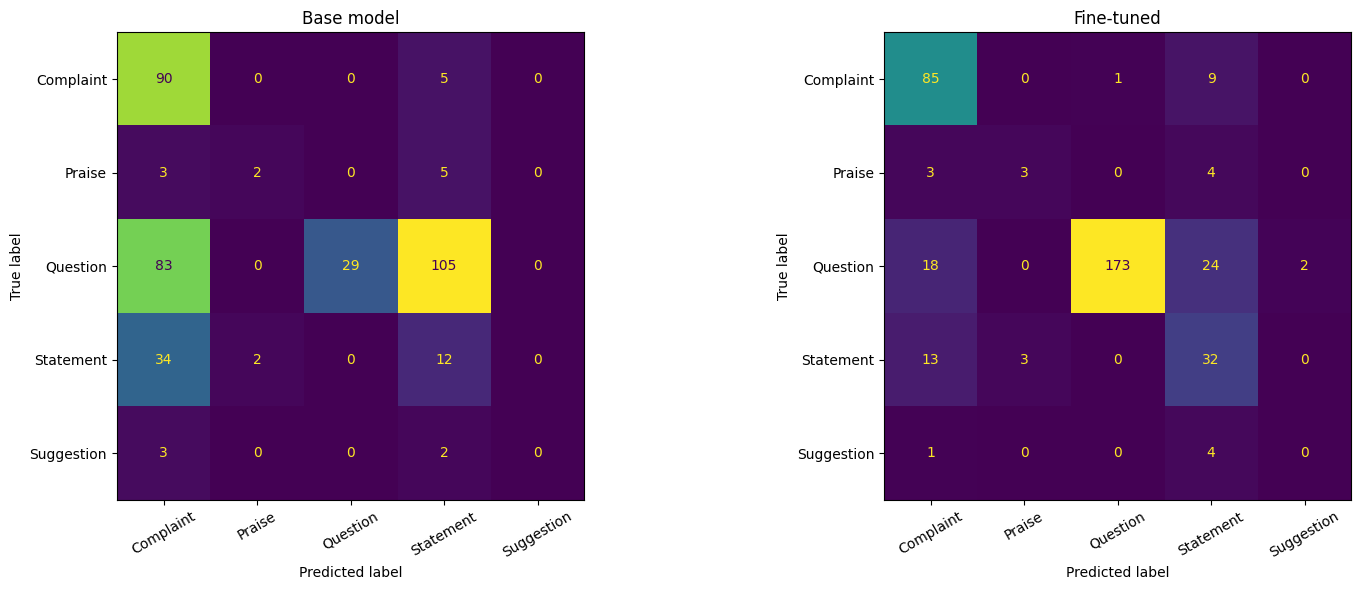

Saved to confusion_matrices.png


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = sorted(VALID_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, title in [
    (axes[0], base_results, "Base model"),
    (axes[1], ft_results,   "Fine-tuned"),
]:
    cm = confusion_matrix(results["y_true"], results["y_pred"], labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved to confusion_matrices.png")

## 8. Save results

In [16]:
import json

output = {
    "base": {
        "accuracy":    base_results["accuracy"],
        "f1_macro":    base_results["f1_macro"],
        "f1_weighted": base_results["f1_weighted"],
        "failed":      base_results["failed"],
        "total":       base_results["total"],
        "report":      base_results["report"],
    },
    "finetuned": {
        "accuracy":    ft_results["accuracy"],
        "f1_macro":    ft_results["f1_macro"],
        "f1_weighted": ft_results["f1_weighted"],
        "failed":      ft_results["failed"],
        "total":       ft_results["total"],
        "report":      ft_results["report"],
    },
}

with open("evaluation_results.json", "w") as f:
    json.dump(output, f, indent=2)

print("Results saved to evaluation_results.json")

Results saved to evaluation_results.json
